In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

# 1. Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()



2025-08-12 18:29:03.336249: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-12 18:29:03.487449: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-12 18:29:03.632758: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755003543.808302    6771 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755003543.844111    6771 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1755003544.108568    6771 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [2]:
# 2. Preprocess the data

# Normalize pixel values to [0, 1]
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape to add channel dimension (for CNNs)
x_train = x_train.reshape(-1, 28, 28, 1)  
x_test = x_test.reshape(-1, 28, 28, 1)

#one hot encoding

y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)


In [3]:
# 3. Build a simple CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),  # Conv layer
    layers.MaxPooling2D((2, 2)),                                           # Pooling layer
    layers.Conv2D(64, (3, 3), activation='relu'),                          # Another Conv
    layers.MaxPooling2D((2, 2)),                                           # Pool again
    layers.Flatten(),                                                     # Flatten to 1D
    layers.Dense(64, activation='relu'),                                  # Dense layer
    layers.Dense(10, activation='softmax')                                # Output layer
])



/home/itachi_uchiha/Desktop/Hue_git/myvenv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-08-12 18:29:13.518327: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [6]:
# 4. Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 5. Train the model
history = model.fit(x_train, y_train, epochs=5)

# 6. Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"\nTest accuracy: {test_acc:.4f}")




2025-08-12 18:30:41.172766: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 188160000 exceeds 10% of free system memory.


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 27ms/step - accuracy: 0.9590 - loss: 0.1358
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 75s 23ms/step - accuracy: 0.9861 - loss: 0.0443
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accuracy: 0.9905 - loss: 0.0302
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 49s 26ms/step - accuracy: 0.9933 - loss: 0.0212
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 52s 28ms/step - accuracy: 0.9946 - loss: 0.0171


2025-08-12 18:35:14.977337: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 31360000 exceeds 10% of free system memory.


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9894 - loss: 0.0351

Test accuracy: 0.9894


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


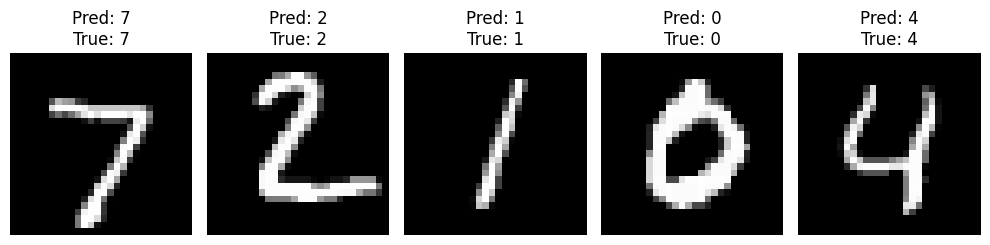

In [8]:

# 7. Visualize a few predictions

import numpy as np
import matplotlib.pyplot as plt

predictions = model.predict(x_test)

plt.figure(figsize=(10, 4))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title(f"Pred: {predictions[i].argmax()}\nTrue: {y_test[i].argmax()}")
    plt.axis('off')
plt.tight_layout()
plt.show()

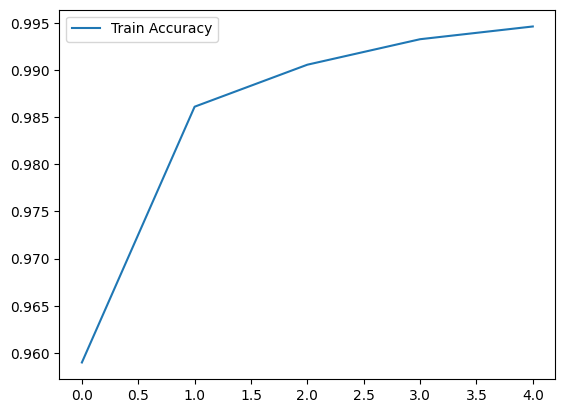

In [13]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.legend()
plt.show()
